In [131]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D

In [132]:
#position of rocket
A_x = float(input("input rocket start x position: "))
A_y = float(input("input rocket start y position: "))
A_z = 0

#end position of rocket
while True: 
    B_x = float(input("input rocket end x position difference of 150 from start x: "))
    B_y = float(input("input rocket end y position difference of 150 from start y: "))

    if ((abs(B_x - A_x) > 150) or (abs(B_y - A_y) > 150)): break

    print("positions too close to A, please enter values further apart")
B_z = 0

#tracker position
while True: 
    C_x = float(input("where do you want to start tracking rocket from x position: "))
    C_y = float(input("where do you want to start tracking rocket from y position: "))

    if ((abs(C_x - A_x) > 100) or (abs(C_y - A_y) > 100)): break

    print("make them further itll be more interesting")
C_z = 0

In [133]:
#change in distance:
dx = B_x - A_x
dy = B_y - A_y

horizontalRange = np.sqrt(dx**2 + dy**2)

#unit directional vectors:
dir_x = dx / horizontalRange
dir_y = dy / horizontalRange

g = 9.81
speed = 100.0

angle = 0.5 * np.arcsin((g * horizontalRange) / speed**2)

vHorizontal = speed * np.cos(angle)
vVertical   = speed * np.sin(angle)

v_x = vHorizontal * dir_x
v_y = vHorizontal * dir_y
v_z = vVertical

#rocket flight time
flightTime = (2 * vVertical) / g

dt = 0.05
n = int(flightTime/dt)

trueX = []
trueY = []
trueZ = []

for i in range(0,n):
    t = i * dt

    trueX.append(A_x + v_x * t)
    trueY.append(A_y + v_y * t)
    trueZ.append(A_z + vVertical * t - 0.5 * g * t**2)

    if trueZ[-1] < 0: trueZ[-1] = 0

trueX = np.array(trueX)
trueY = np.array(trueY)
trueZ = np.array(trueZ)

radar_noise_std = 2.0

measurements_x = trueX + np.random.normal(0, radar_noise_std, n)
measurements_y = trueY + np.random.normal(0, radar_noise_std, n)
measurements_z = trueZ + np.random.normal(0, radar_noise_std, n)

In [134]:
#[x, y, z, dx, dy, dz]
x = np.array([[A_x],
              [A_y],
              [0.0],
              [v_x],
              [v_y],
              [vVertical]])

# initial covariance
P = np.eye(6) * 1000

# state transition matrix
F = np.array([[1,  0,  0,  dt, 0,  0  ],
              [0,  1,  0,  0,  dt, 0  ],
              [0,  0,  1,  0,  0,  dt ],
              [0,  0,  0,  1,  0,  0  ],
              [0,  0,  0,  0,  1,  0  ],
              [0,  0,  0,  0,  0,  1  ]])

H = np.array([[1, 0, 0, 0, 0, 0],
              [0, 1, 0, 0, 0, 0],
              [0, 0, 1, 0, 0, 0]], dtype=float)

Q = np.eye(6) * 0.01
R = np.eye(3) * radar_noise_std**2
I = np.eye(6)

In [135]:
storedCx = C_x
storedCy = C_y
storedCz = 0.0

dC_x = A_x - C_x
dC_y = A_y - C_y
dC_z = 0

distance = np.sqrt(dC_x**2 + dC_y**2 + dC_z**2)

dir_Cx = dC_x / distance
dir_Cy = dC_y / distance
dir_Cz = dC_z / distance

interceptor_speed = speed * 15

C_vx = interceptor_speed * dir_Cx
C_vy = interceptor_speed * dir_Cy
C_vz = interceptor_speed * dir_Cz

C_xPath = [C_x]
C_yPath = [C_y]
C_zPath = [0.0]

intercept_achieved = False
intercept_index    = None

estimatesX = []
estimatesY = []
estimatesZ = []

In [136]:
for i in range(0, n):
    z = np.array([[measurements_x[i]], 
                  [measurements_y[i]], 
                  [measurements_z[i]]])
    x = F @ x
    x[5][0] -= g * dt 
    P = F @ P @ F.T + Q

    #residual
    y = z - H @ x
    #total measurement uncertainty
    S = H @ P @ H.T + R
    #np.linalg.inv(S) calculates matrix inverse
    #Kalman Gain
    K = P @ H.T @ np.linalg.inv(S)
    
    x = x + K @ y

    #Joseph form covariance update
    P = (I - K @ H) @ P @ (I - K @ H).T + K @ R @ K.T

    #store estimates
    estimatesX.append(x[0][0])
    estimatesY.append(x[1][0])
    estimatesZ.append(x[2][0])

    #predicted position from KF
    pred_x = x[0][0]
    pred_y = x[1][0]
    pred_z = x[2][0]
    
    #direction from interceptor to predicted position
    delta_x  = pred_x - storedCx
    delta_y  = pred_y - storedCy
    delta_z  = pred_z - storedCz
    distance = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)

    dir_x = delta_x / distance
    dir_y = delta_y / distance
    dir_z = delta_z / distance

    #interceptor velocity toward measured position of rocket
    C_vx = speed * dir_x
    C_vy = speed * dir_y
    C_vz = speed * dir_z

    storedCx = storedCx + C_vx * dt
    storedCy = storedCy + C_vy * dt
    storedCz = storedCz + C_vz * dt

    #has to be above 0 or else itll be inside the ground
    if storedCz < 0: storedCz = 0

    C_xPath.append(storedCx)
    C_yPath.append(storedCy)
    C_zPath.append(storedCz)

    #distance interceptor from the distance of where the rocket is 
    intercept_distance = np.sqrt(
        (storedCx - estimatesX[-1])**2 +
        (storedCy - estimatesY[-1])**2 +
        (storedCz - estimatesZ[-1])**2)

    if intercept_distance < 5.0:
        intercept_achieved = True
        intercept_index    = i
        intercept_x = storedCx
        intercept_y = storedCy
        intercept_z = storedCz
        break

print("A:", A_x, A_y)
print("B:", B_x, B_y)  
print("C:", C_x, C_y)
print("total flight steps:", n)
print("intercept at step:", intercept_index, "out of", n)
print("rocket position at intercept:", trueX[intercept_index], trueY[intercept_index], trueZ[intercept_index])

if intercept_achieved:
    print(f"intercept achieved at timestep {intercept_index}")
    print(f"intercept position x: {storedCx:.1f} y: {storedCy:.1f} z: {storedCz:.1f}")
else:
    print("no intercept achieved — try adjusting interceptor start position or speed")

print("estimatesX length:", len(estimatesX))
print("C_xPath length:   ", len(C_xPath))
print("intercept_index:  ", intercept_index)

A: 5.0 20.0
B: 400.0 500.0
C: 600.0 730.0
total flight steps: 131
intercept at step: 95 out of 131
rocket position at intercept: 290.7442680589889 367.2335409324421 42.31486254753814
intercept achieved at timestep 95
intercept position x: 290.2 y: 367.2 z: 43.2
estimatesX length: 96
C_xPath length:    97
intercept_index:   95


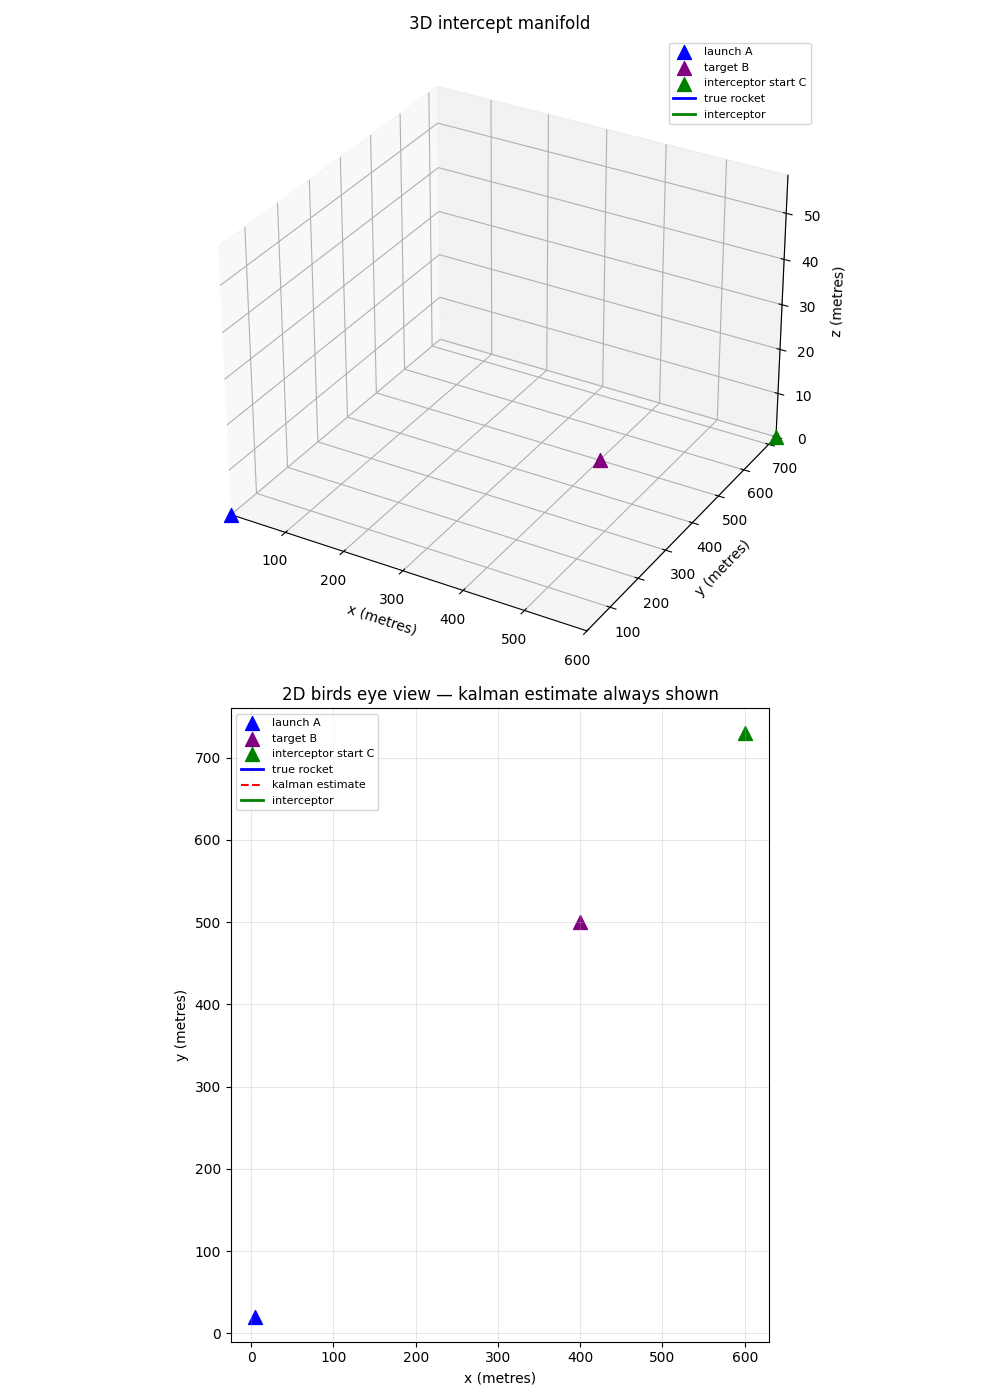

In [137]:
# ask user if they want kalman filter shown on 3D graph
show_kalman_3d = input("show kalman filter estimate on 3D graph? (yes/no): ").strip().lower() == 'yes'

fig = plt.figure(figsize=(10, 14))

# --- TOP — 3D manifold ---
ax1 = fig.add_subplot(211, projection='3d')
ax1.set_xlabel('x (metres)')
ax1.set_ylabel('y (metres)')
ax1.set_zlabel('z (metres)')
ax1.set_title('3D intercept manifold')
ax1.set_xlim(min(trueX.min(), C_x), max(trueX.max(), C_x))
ax1.set_ylim(min(trueY.min(), C_y), max(trueY.max(), C_y))
ax1.set_zlim(0, trueZ.max() * 1.1)

ax1.scatter(A_x, A_y, 0, color='blue',   s=100, marker='^', label='launch A')
ax1.scatter(B_x, B_y, 0, color='purple', s=100, marker='^', label='target B')
ax1.scatter(C_x, C_y, 0, color='green',  s=100, marker='^', label='interceptor start C')

rocket_line_3d,    = ax1.plot([], [], [], color='blue',  linewidth=2,   label='true rocket')
intercept_line_3d, = ax1.plot([], [], [], color='green', linewidth=2,   label='interceptor')
intercept_point_3d = ax1.scatter([], [], [], color='red', s=250, marker='x', linewidth=3, zorder=5)

if show_kalman_3d:
    kalman_line_3d, = ax1.plot([], [], [], color='red', linewidth=1.5, linestyle='--', label='kalman estimate')
else:
    kalman_line_3d, = ax1.plot([], [], [], color='red', linewidth=0)

ax1.legend(fontsize=8)

# --- BOTTOM — 2D birds eye (kalman always shown) ---
ax2 = fig.add_subplot(212)
ax2.set_xlabel('x (metres)')
ax2.set_ylabel('y (metres)')
ax2.set_title('2D birds eye view — kalman estimate always shown')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')
ax2.set_xlim(min(trueX.min(), C_x) - 30, max(trueX.max(), C_x) + 30)
ax2.set_ylim(min(trueY.min(), C_y) - 30, max(trueY.max(), C_y) + 30)

ax2.scatter(A_x, A_y, color='blue',   s=100, marker='^', label='launch A')
ax2.scatter(B_x, B_y, color='purple', s=100, marker='^', label='target B')
ax2.scatter(C_x, C_y, color='green',  s=100, marker='^', label='interceptor start C')

rocket_line_2d,    = ax2.plot([], [], color='blue',  linewidth=2,         label='true rocket')
kalman_line_2d,    = ax2.plot([], [], color='red',   linewidth=1.5,
                               linestyle='--',                             label='kalman estimate')
intercept_line_2d, = ax2.plot([], [], color='green', linewidth=2,         label='interceptor')
intercept_point_2d = ax2.scatter([], [], color='red', s=250, marker='x',  zorder=5)
ax2.legend(fontsize=8)

# --- smoothing settings ---
smoothing         = 3
hold_frames       = 20
total_data_frames = intercept_index + 1 if intercept_achieved else n
total_frames      = total_data_frames * smoothing + hold_frames

def update(frame):
    real_frame = min(frame // smoothing, total_data_frames - 1)
    f = real_frame + 1

    # 3D updates
    rocket_line_3d.set_data(trueX[:f], trueY[:f])
    rocket_line_3d.set_3d_properties(trueZ[:f])

    intercept_line_3d.set_data(C_xPath[:f], C_yPath[:f])
    intercept_line_3d.set_3d_properties(C_zPath[:f])

    if show_kalman_3d:
        kalman_line_3d.set_data(estimatesX[:f], estimatesY[:f])
        kalman_line_3d.set_3d_properties(estimatesZ[:f])

    # 2D updates — kalman always drawn
    rocket_line_2d.set_data(trueX[:f],      trueY[:f])
    kalman_line_2d.set_data(estimatesX[:f], estimatesY[:f])
    intercept_line_2d.set_data(C_xPath[:f], C_yPath[:f])

    # intercept marker
    if intercept_achieved and real_frame >= intercept_index:
        intercept_point_3d._offsets3d = ([intercept_x], [intercept_y], [intercept_z])
        intercept_point_2d.set_offsets([[intercept_x, intercept_y]])

    return (rocket_line_3d, kalman_line_3d, intercept_line_3d,
            rocket_line_2d, kalman_line_2d, intercept_line_2d)

ani = animation.FuncAnimation(
    fig,
    update,
    frames=total_frames,
    interval=20,
    blit=False,
    repeat=False
)

plt.tight_layout()
plt.show()